In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
df=pd.read_csv("diabetes_dataset00.csv")

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Target                         70000 non-null  object
 1   Genetic Markers                70000 non-null  object
 2   Autoantibodies                 70000 non-null  object
 3   Family History                 70000 non-null  object
 4   Environmental Factors          70000 non-null  object
 5   Insulin Levels                 70000 non-null  int64 
 6   Age                            70000 non-null  int64 
 7   BMI                            70000 non-null  int64 
 8   Physical Activity              70000 non-null  object
 9   Dietary Habits                 70000 non-null  object
 10  Blood Pressure                 70000 non-null  int64 
 11  Cholesterol Levels             70000 non-null  int64 
 12  Waist Circumference            70000 non-null  int64 
 13  B

In [118]:
df.shape

(70000, 34)

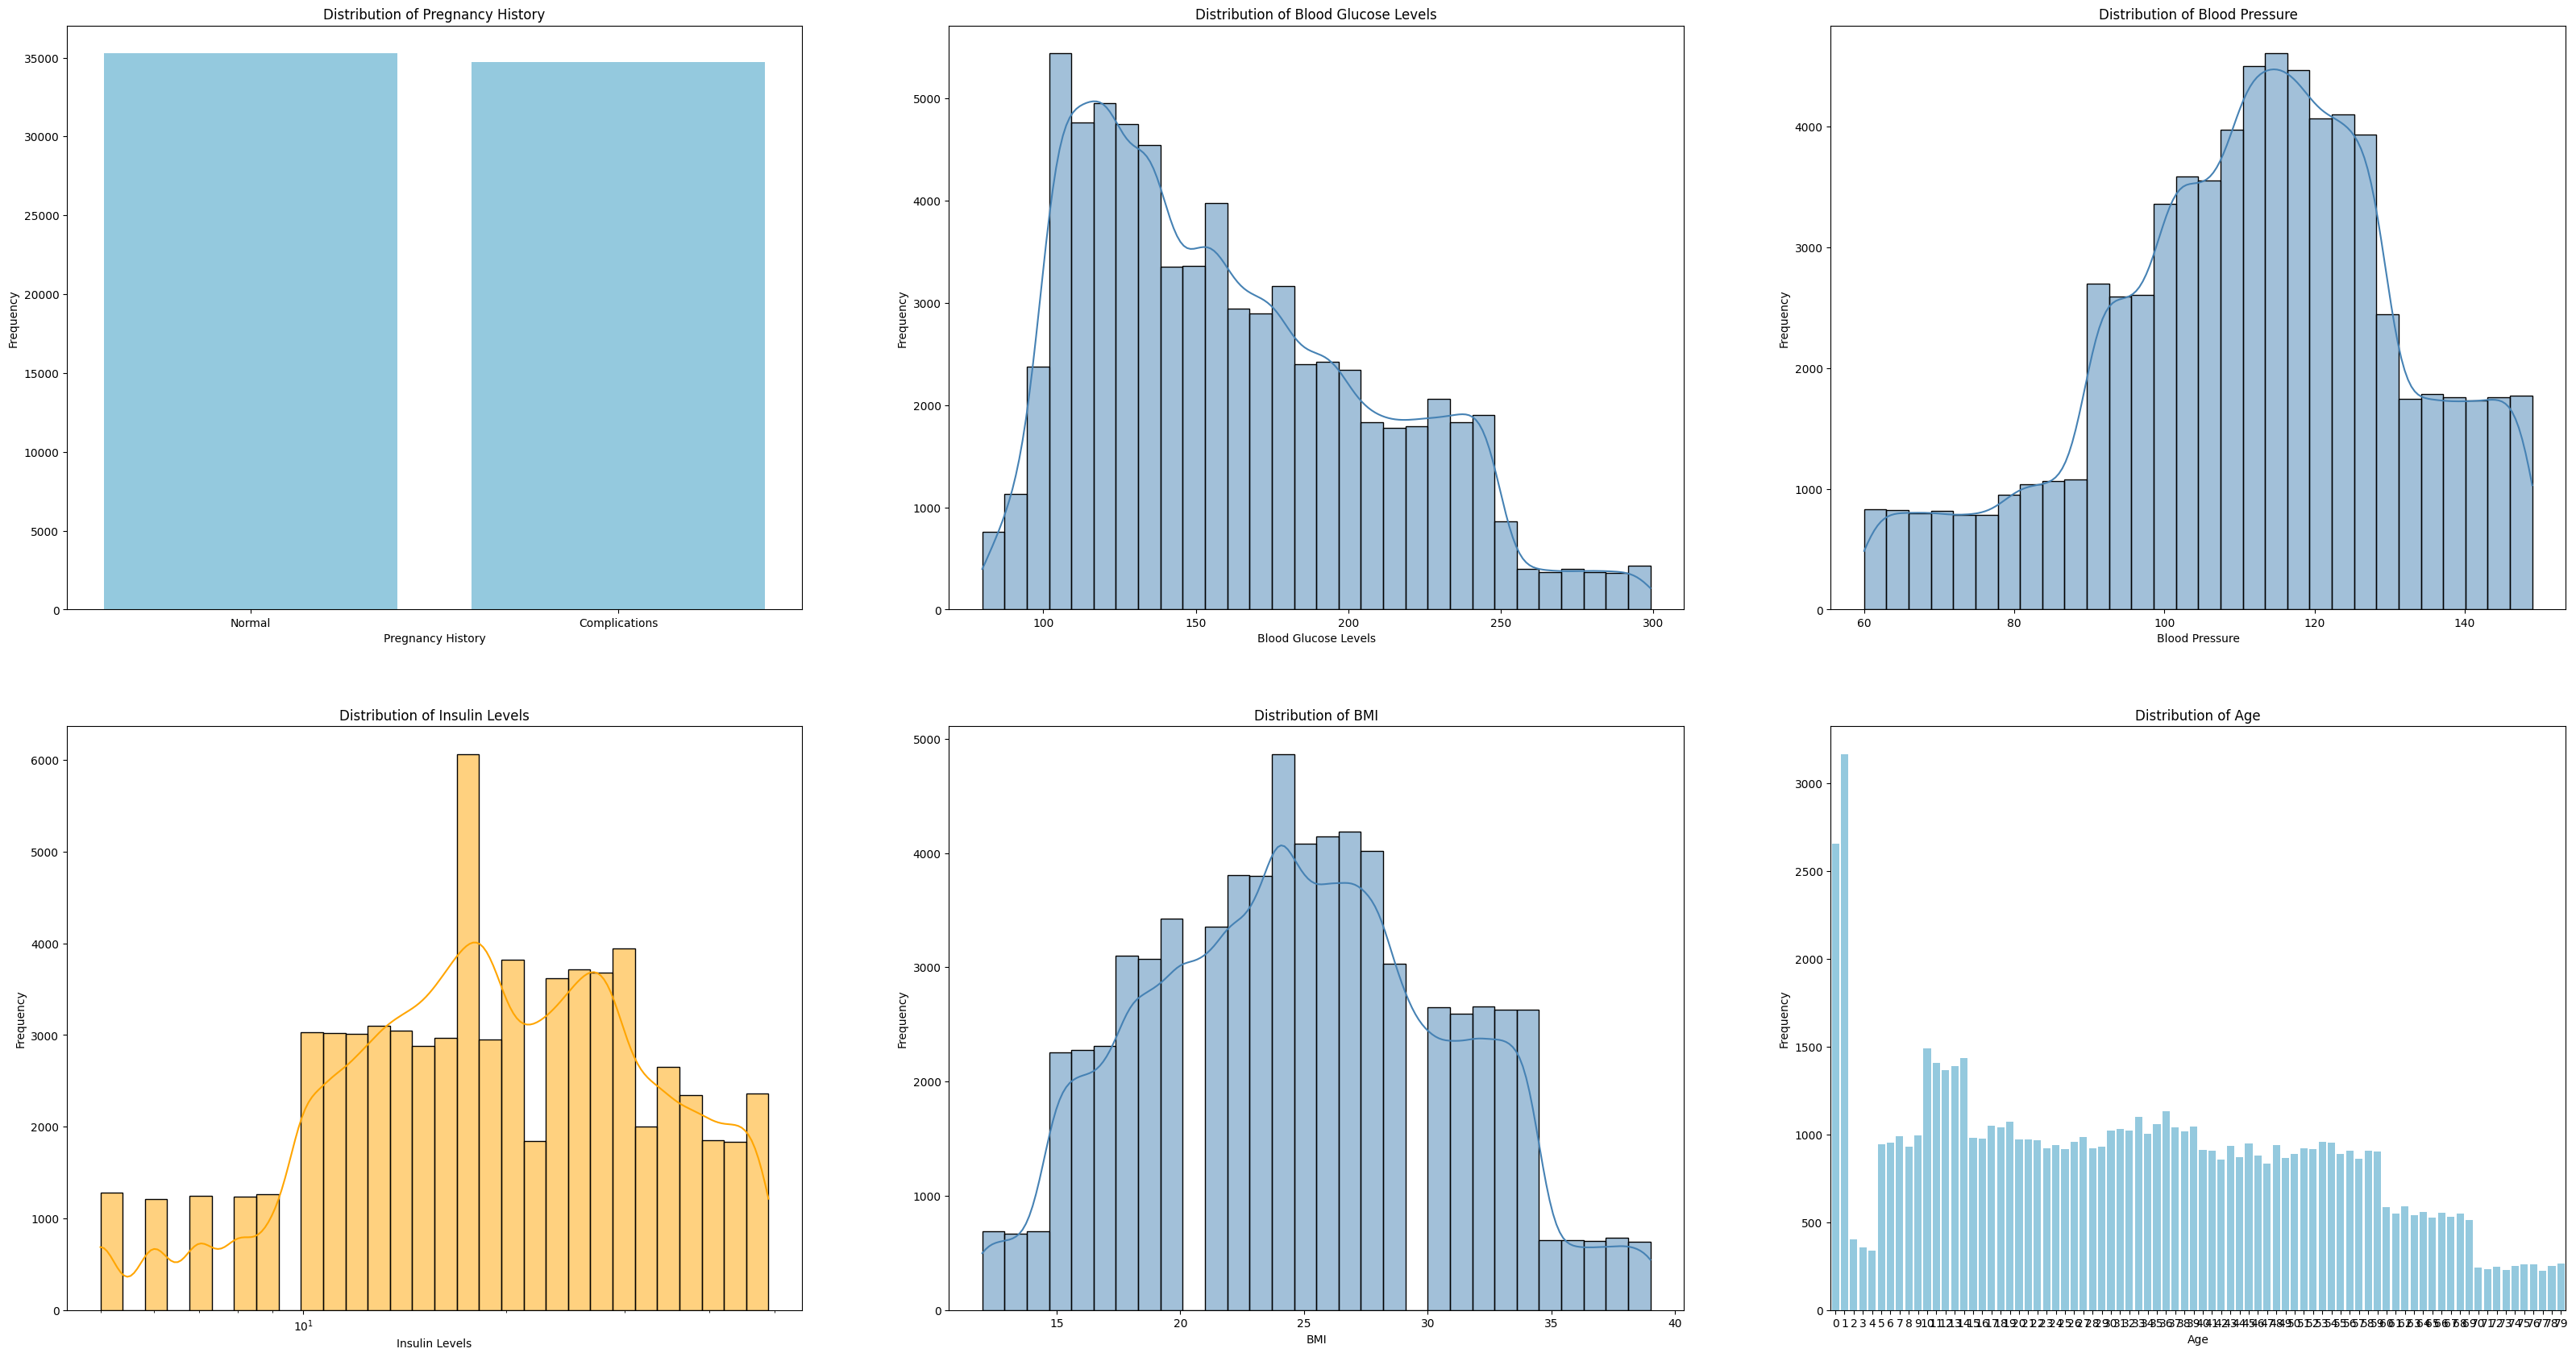

In [119]:
features = [
    "Pregnancy History", "Blood Glucose Levels", "Blood Pressure",
    "Insulin Levels", "BMI", "Age"
]

plt.figure(figsize=(40, 32))
for i, col in enumerate(features):
    plt.subplot(3, 3, i + 1)

    if col == "Insulin Levels":
        sns.histplot(df[col], kde=True, bins=30, log_scale=True, color='orange')
    elif col == "Pregnancy History" or col == "Age":
        sns.countplot(x=col, data=df, color='skyblue')
    else:
        sns.histplot(df[col], kde=True, bins=30, color='steelblue')

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')


In [120]:
print("Average age of patients:",df['Age'].mean())
print("Average BMI of patients:",df['BMI'].mean())
print("Average Glucose Levels of patients:",df['Blood Glucose Levels'].mean())

Average age of patients: 32.0207
Average BMI of patients: 24.782942857142856
Average Glucose Levels of patients: 160.70165714285713


In [121]:
df.columns

Index(['Target', 'Genetic Markers', 'Autoantibodies', 'Family History',
       'Environmental Factors', 'Insulin Levels', 'Age', 'BMI',
       'Physical Activity', 'Dietary Habits', 'Blood Pressure',
       'Cholesterol Levels', 'Waist Circumference', 'Blood Glucose Levels',
       'Ethnicity', 'Socioeconomic Factors', 'Smoking Status',
       'Alcohol Consumption', 'Glucose Tolerance Test', 'History of PCOS',
       'Previous Gestational Diabetes', 'Pregnancy History',
       'Weight Gain During Pregnancy', 'Pancreatic Health',
       'Pulmonary Function', 'Cystic Fibrosis Diagnosis',
       'Steroid Use History', 'Genetic Testing', 'Neurological Assessments',
       'Liver Function Tests', 'Digestive Enzyme Levels', 'Urine Test',
       'Birth Weight', 'Early Onset Symptoms'],
      dtype='object')

In [122]:
df

,Target,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,...,Pulmonary Function,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms
0,Steroid-Induced Diabetes,Positive,Negative,No,Present,40,44,38,High,Healthy,...,76,No,No,Positive,3,Normal,56,Ketones Present,2629,No
1,Neonatal Diabetes Mellitus (NDM),Positive,Negative,No,Present,13,1,17,High,Healthy,...,60,Yes,No,Negative,1,Normal,28,Glucose Present,1881,Yes
2,Prediabetic,Positive,Positive,Yes,Present,27,36,24,High,Unhealthy,...,80,Yes,No,Negative,1,Abnormal,55,Ketones Present,3622,Yes
3,Type 1 Diabetes,Negative,Positive,No,Present,8,7,16,Low,Unhealthy,...,89,Yes,No,Positive,2,Abnormal,60,Ketones Present,3542,No
4,Wolfram Syndrome,Negative,Negative,Yes,Present,17,10,17,High,Healthy,...,41,No,No,Positive,1,Normal,24,Protein Present,1770,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,Steroid-Induced Diabetes,Negative,Negative,Yes,Present,24,38,35,High,Unhealthy,...,71,Yes,Yes,Positive,2,Abnormal,34,Normal,2575,No
69996,LADA,Positive,Positive,No,Absent,21,51,31,Low,Unhealthy,...,82,Yes,Yes,Negative,1,Abnormal,58,Ketones Present,3002,No
69997,Type 1 Diabetes,Positive,Negative,No,Absent,18,11,15,Low,Unhealthy,...,77,Yes,Yes,Positive,2,Normal,53,Protein Present,3593,No
69998,Cystic Fibrosis-Related Diabetes (CFRD),Positive,Negative,No,Absent,32,30,24,High,Healthy,...,70,No,No,Positive,1,Abnormal,35,Ketones Present,2592,Yes


C:\Users\nrakesh\AppData\Local\Temp\ipykernel_6284\3732040562.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target', data=df, palette='Set2')


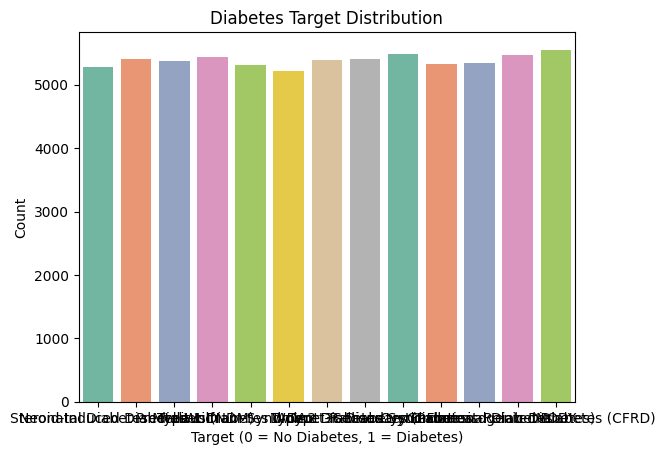

In [123]:
df['Target'].value_counts()
df['Target'].value_counts(normalize=True) * 100

sns.countplot(x='Target', data=df, palette='Set2')
plt.title('Diabetes Target Distribution')
plt.xlabel('Target (0 = No Diabetes, 1 = Diabetes)')
plt.ylabel('Count')
plt.show()


In [124]:
df.groupby('Target').mean(numeric_only=True)


,Insulin Levels,Age,BMI,Blood Pressure,Cholesterol Levels,Waist Circumference,Blood Glucose Levels,Weight Gain During Pregnancy,Pancreatic Health,Pulmonary Function,Neurological Assessments,Digestive Enzyme Levels,Birth Weight
Target,,,,,,,,,,,,,
Cystic Fibrosis-Related Diabetes (CFRD),24.467240,24.416179,25.974012,109.129392,184.516288,33.517387,140.053990,16.987921,49.404100,69.426611,1.508602,54.494693,3254.095900
Gestational Diabetes,19.376497,29.503181,27.053518,114.488398,199.565120,35.557822,114.534993,19.483907,54.535741,79.474925,1.505052,54.276385,3506.059506
LADA,24.367796,44.447253,27.061076,114.323569,194.813900,36.993873,129.740188,12.111813,59.654030,79.498373,1.489948,49.373157,3251.660348
MODY,19.531424,19.584909,23.382316,104.472898,174.596975,31.536467,109.324509,12.023951,54.251576,79.530524,1.492527,49.589411,3258.766613
Neonatal Diabetes Mellitus (NDM),9.473928,0.509061,15.473558,69.473373,149.525333,24.452478,159.173817,4.527367,24.492234,64.320266,1.498521,19.535133,2252.943602
Prediabetic,19.550967,44.315476,25.980283,119.600632,209.914435,35.508743,111.997768,19.592262,54.377604,79.518415,1.500186,59.560268,3252.718006
Secondary Diabetes,29.847600,59.488958,27.992152,129.572732,239.813470,41.471254,199.580033,27.080489,59.246943,69.451542,2.494798,59.494981,3494.878627
Steroid-Induced Diabetes,31.838483,49.500095,29.469573,129.638673,249.479810,44.459336,189.412322,22.056303,49.695545,69.387299,2.507488,49.256303,3487.466351
Type 1 Diabetes,12.087587,17.065002,19.517260,104.359714,174.515057,30.521116,124.373669,14.593279,54.384870,79.632758,1.488065,49.520749,3251.773228


In [125]:
df.groupby("Target")["Blood Glucose Levels"].mean()


Target
Cystic Fibrosis-Related Diabetes (CFRD)       140.053990
Gestational Diabetes                          114.534993
LADA                                          129.740188
MODY                                          109.324509
Neonatal Diabetes Mellitus (NDM)              159.173817
Prediabetic                                   111.997768
Secondary Diabetes                            199.580033
Steroid-Induced Diabetes                      189.412322
Type 1 Diabetes                               124.373669
Type 2 Diabetes                               164.084121
Type 3c Diabetes (Pancreatogenic Diabetes)    199.970113
Wolcott-Rallison Syndrome                     200.147407
Wolfram Syndrome                              249.101599
Name: Blood Glucose Levels, dtype: float64

Text(0.5, 1.0, ' Age vs Blood Glucose Levels')

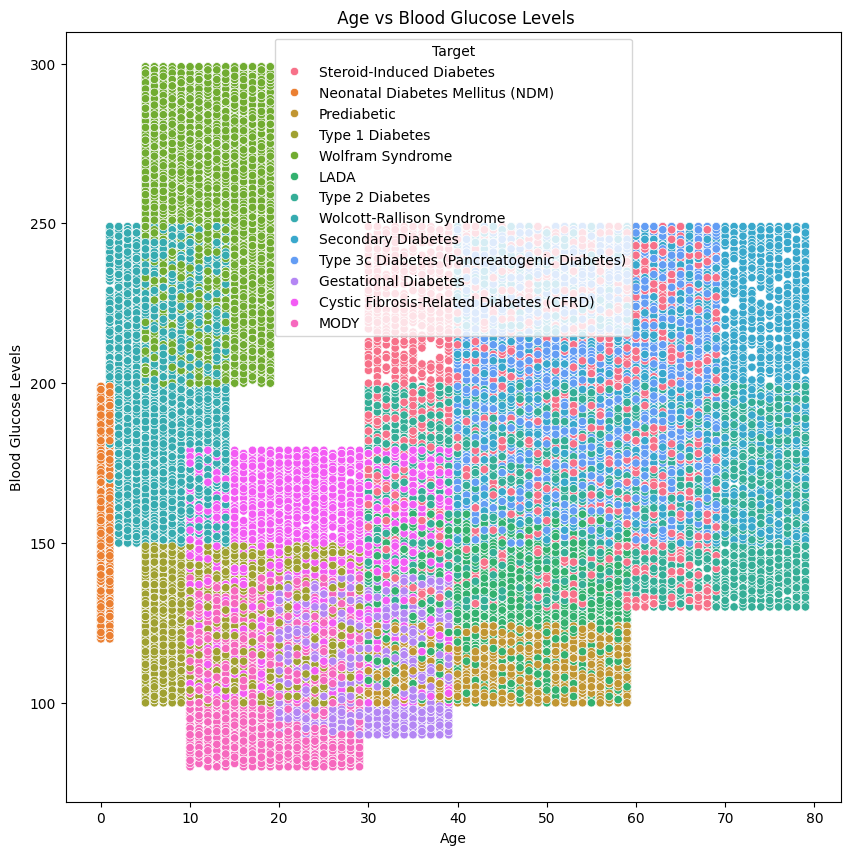

In [126]:
plt.figure(figsize=(10, 10))
sns.scatterplot(x="Age", y="Blood Glucose Levels", hue="Target", data=df)
plt.title(" Age vs Blood Glucose Levels")


Text(0.5, 1.0, 'BMI by Target')

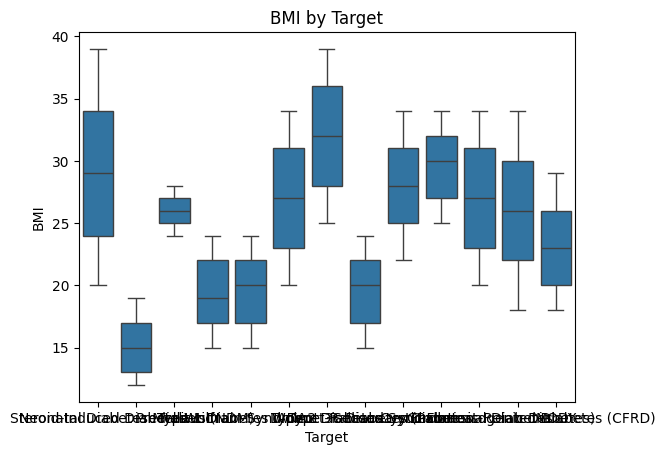

In [127]:
plt.figure()
sns.boxplot(x="Target", y="BMI", data=df)
plt.title("BMI by Target")

Text(0.5, 1.0, 'Correlation Heatmap')

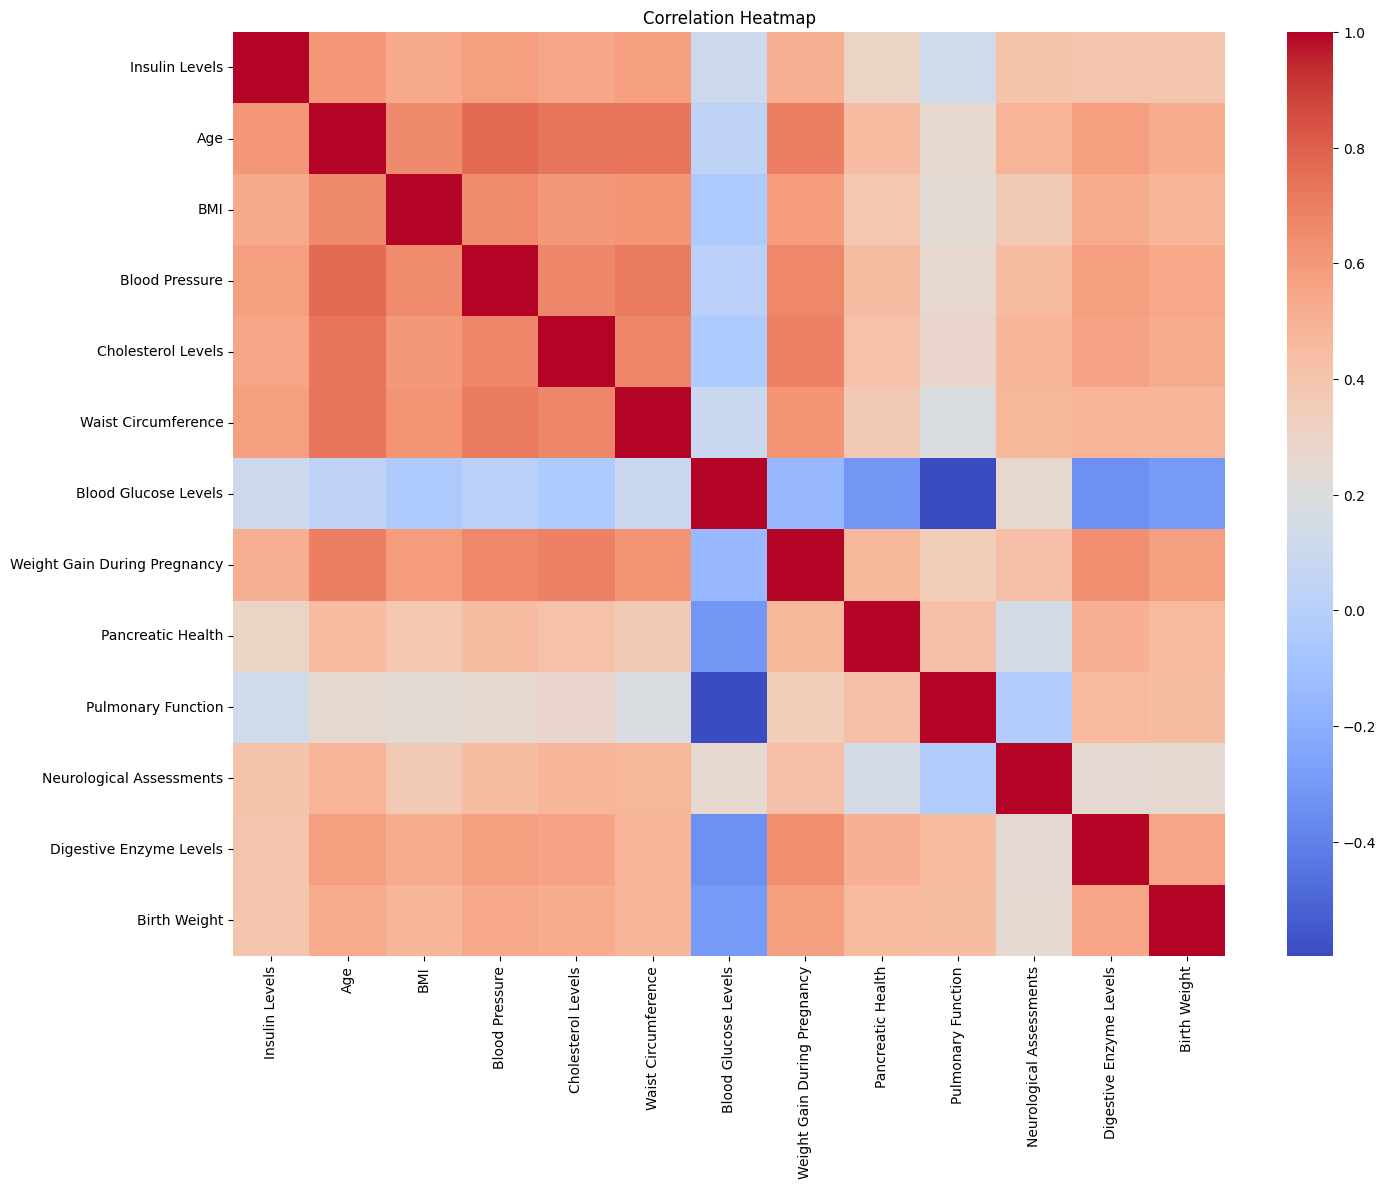

In [128]:
plt.figure(figsize=(16,12))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")


In [129]:
df.groupby("Target").mean(numeric_only=True).diff().iloc[-1].abs().sort_values(ascending=False).head(5)


Birth Weight            245.251438
Blood Glucose Levels     48.954192
Pulmonary Function        5.041781
Age                       4.433756
Insulin Levels            2.479886
Name: Wolfram Syndrome, dtype: float64

In [130]:
df["AgeGroup"] = pd.cut(df["Age"], bins=[0,30,50,100], labels=["<30", "30–50", ">50"])
df.AgeGroup.value_counts

<bound method IndexOpsMixin.value_counts of 0        30–50
1          <30
2        30–50
3          <30
4          <30
         ...  
69995    30–50
69996      >50
69997      <30
69998      <30
69999    30–50
Name: AgeGroup, Length: 70000, dtype: category
Categories (3, object): ['<30' < '30–50' < '>50']>

In [131]:
df.groupby("Pregnancy History")[["Blood Glucose Levels", "Insulin Levels"]].mean()


,Blood Glucose Levels,Insulin Levels
Pregnancy History,,
Complications,160.803081,21.657040
Normal,160.601786,21.558605


Text(0.5, 1.0, 'Average BMI per Age Group')

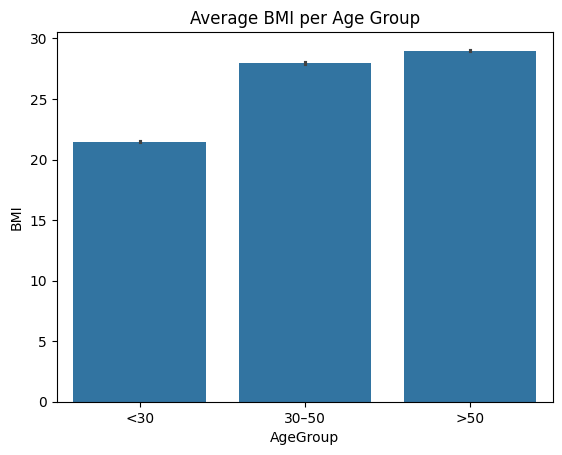

In [132]:
plt.figure()
sns.barplot(x="AgeGroup", y="BMI", data=df)
plt.title("Average BMI per Age Group")

In [133]:
df.nlargest(5, "Age")[["Age", "Blood Glucose Levels", "Insulin Levels", "Target"]]


,Age,Blood Glucose Levels,Insulin Levels,Target
147,79,173,32,Secondary Diabetes
560,79,158,32,Type 2 Diabetes
657,79,210,14,Secondary Diabetes
823,79,156,41,Type 2 Diabetes
1508,79,248,34,Secondary Diabetes


Text(0.5, 1.0, 'Q15: Pregnancy History vs Diabetes Rate')

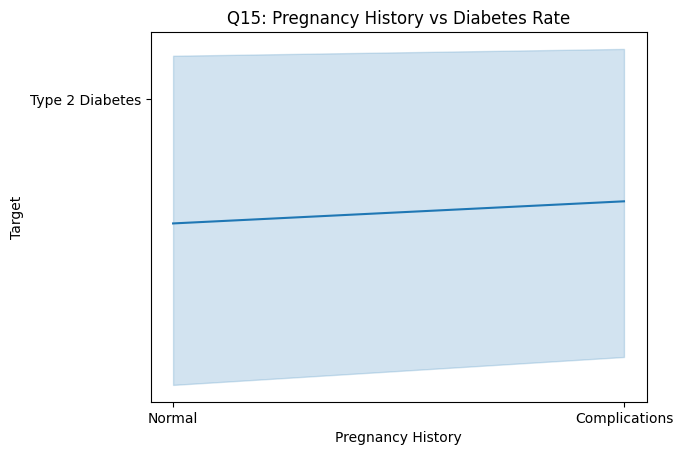

In [134]:
plt.figure()
sns.lineplot(x="Pregnancy History", y="Target", data=df)
plt.title("Q15: Pregnancy History vs Diabetes Rate")

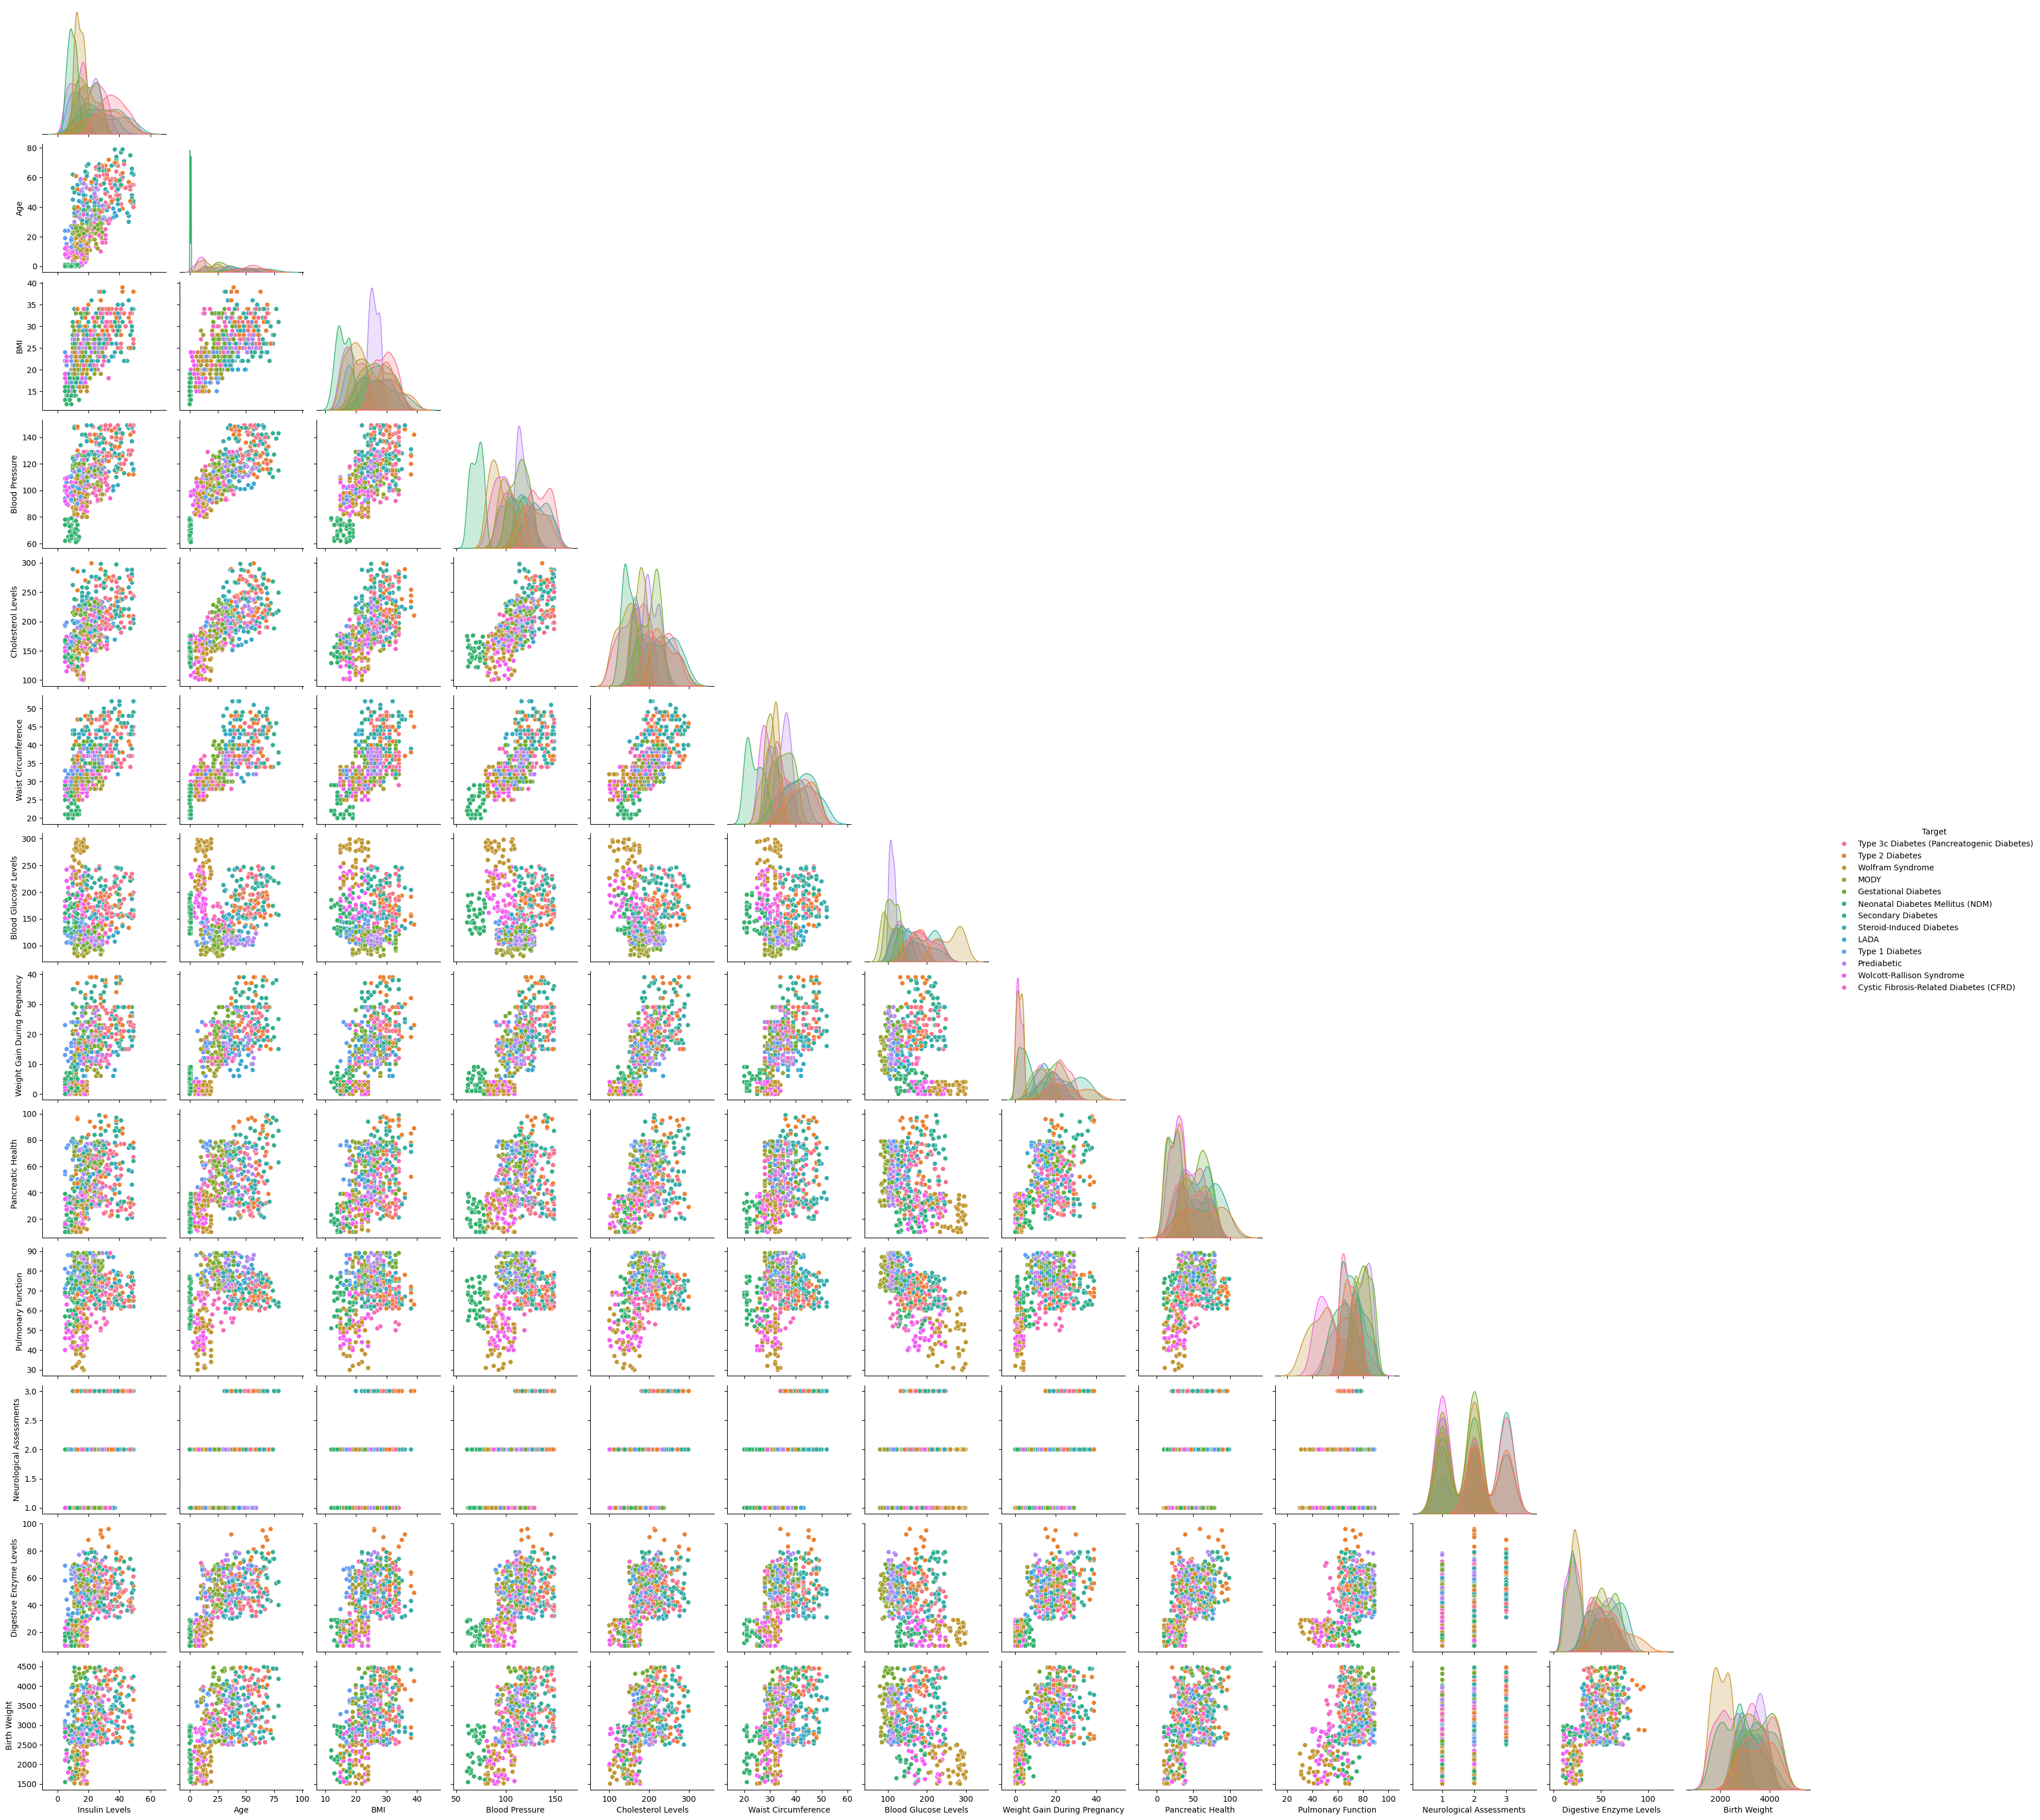

In [135]:
sample_df = df.select_dtypes(include=[np.number])
if len(sample_df) > 500:
    sample_df = sample_df.sample(500)
sample_df["Target"] = df["Target"]
sns.pairplot(sample_df, hue="Target", corner=True)

Text(0.5, 1.0, 'BMI by Target (Violin)')

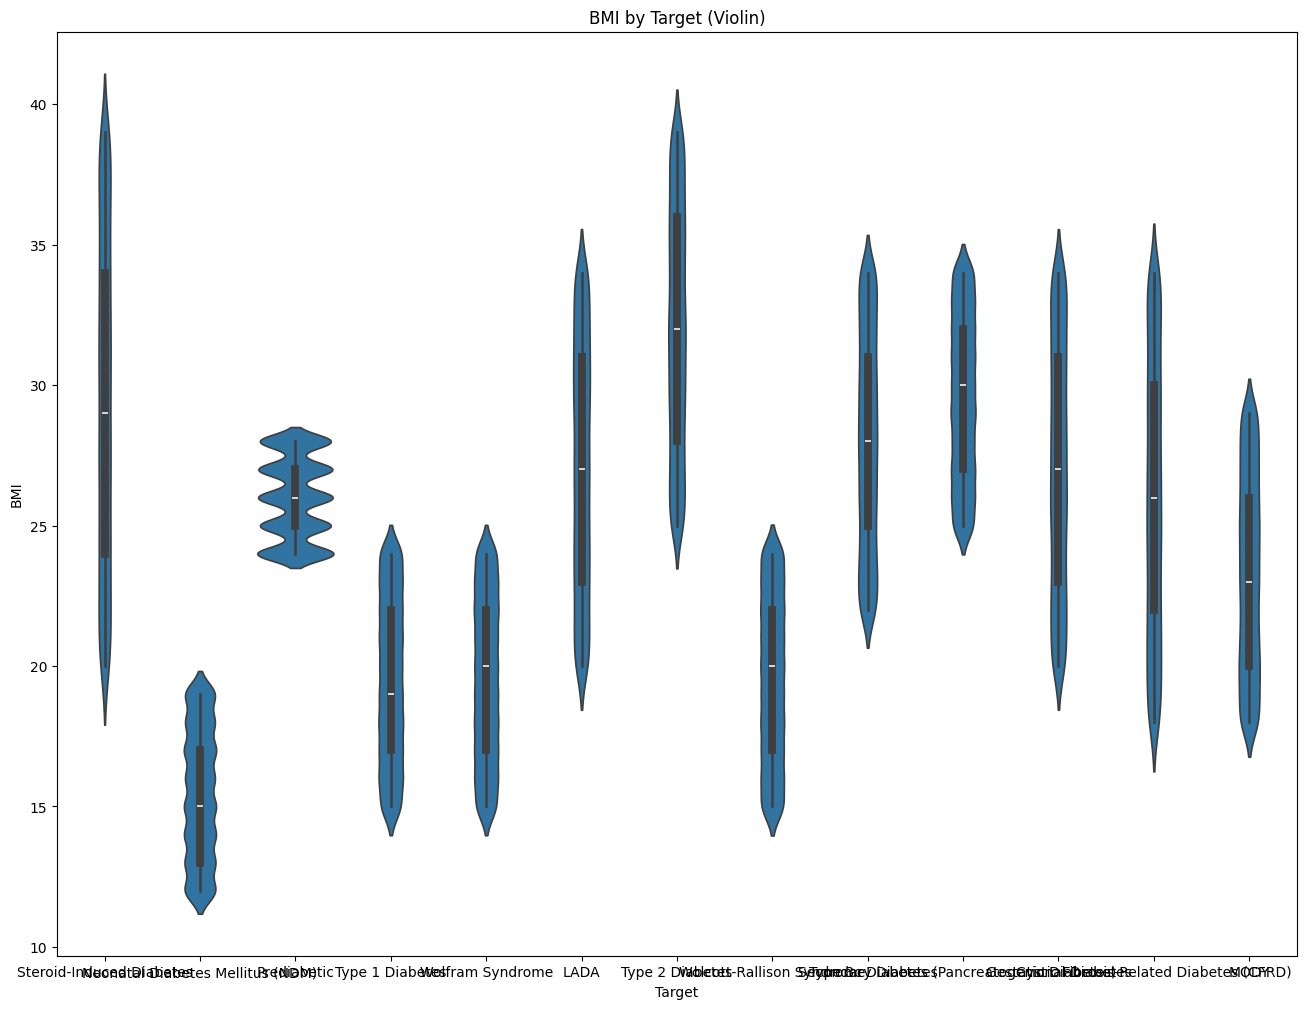

In [136]:
plt.figure(figsize=(16,12))
sns.violinplot(x="Target", y="BMI", data=df)
plt.title("BMI by Target (Violin)")

Text(0.5, 1.0, 'Outlier Detection')

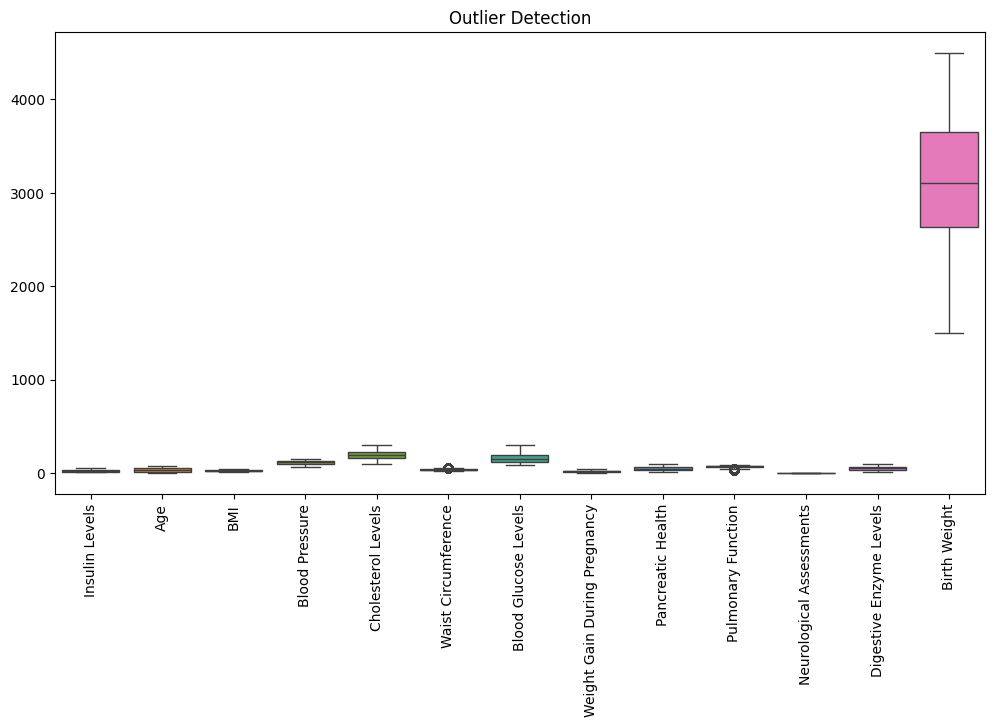

In [137]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include=[np.number]))
plt.xticks(rotation=90)
plt.title("Outlier Detection")

In [138]:
df

,Target,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,...,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms,AgeGroup
0,Steroid-Induced Diabetes,Positive,Negative,No,Present,40,44,38,High,Healthy,...,No,No,Positive,3,Normal,56,Ketones Present,2629,No,30–50
1,Neonatal Diabetes Mellitus (NDM),Positive,Negative,No,Present,13,1,17,High,Healthy,...,Yes,No,Negative,1,Normal,28,Glucose Present,1881,Yes,<30
2,Prediabetic,Positive,Positive,Yes,Present,27,36,24,High,Unhealthy,...,Yes,No,Negative,1,Abnormal,55,Ketones Present,3622,Yes,30–50
3,Type 1 Diabetes,Negative,Positive,No,Present,8,7,16,Low,Unhealthy,...,Yes,No,Positive,2,Abnormal,60,Ketones Present,3542,No,<30
4,Wolfram Syndrome,Negative,Negative,Yes,Present,17,10,17,High,Healthy,...,No,No,Positive,1,Normal,24,Protein Present,1770,No,<30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,Steroid-Induced Diabetes,Negative,Negative,Yes,Present,24,38,35,High,Unhealthy,...,Yes,Yes,Positive,2,Abnormal,34,Normal,2575,No,30–50
69996,LADA,Positive,Positive,No,Absent,21,51,31,Low,Unhealthy,...,Yes,Yes,Negative,1,Abnormal,58,Ketones Present,3002,No,>50
69997,Type 1 Diabetes,Positive,Negative,No,Absent,18,11,15,Low,Unhealthy,...,Yes,Yes,Positive,2,Normal,53,Protein Present,3593,No,<30
69998,Cystic Fibrosis-Related Diabetes (CFRD),Positive,Negative,No,Absent,32,30,24,High,Healthy,...,No,No,Positive,1,Abnormal,35,Ketones Present,2592,Yes,<30
